### 지방자치단체에서 인/허가한 업종별 데이터를 가지고 데이터 분석 및 시각화하셔요
- 서울시 서대문구에서 치킨집이 가장 많은 동은?
- 서울시 구별 치킨집 현황(갯수) 등

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import json
import platform
import matplotlib.font_manager as font_manager
import matplotlib as mpl

system = platform.system()
if system == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
elif system == "Darwin":
    font_path = "/System/Library/Fonts/AppleSDGothicNeo.ttc"
elif system == "Linux":
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
else:
    font_path = None
if font_path:
    font = font_manager.FontProperties(fname=font_path).get_name()
    mpl.rcParams['font.family'] = font
else:
    print("폰트 경로를 확인해주세요.")

mpl.rcParams['axes.unicode_minus'] = False

#여러변수출력코드
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity="all"

In [19]:
chicken_df = pd.read_csv(
    "../../data/서울특별시_일반음식점.csv",
    encoding="cp949",
    low_memory=False,
    usecols=['개방자치단체코드', '상세영업상태코드', '상세영업상태명', '소재지전체주소', '도로명전체주소', '업태구분명', '위생업태명']
)

In [31]:
len(chicken_df)
chicken_df.head()

472915

,개방자치단체코드,상세영업상태코드,상세영업상태명,소재지전체주소,도로명전체주소,업태구분명,위생업태명
0,3150000,1,영업,서울특별시 강서구 마곡동 757 두산더랜드파크 B동 207호,"서울특별시 강서구 마곡중앙로 161-8, 두산더랜드파크 B동 2층 207호 (마곡동)",한식,한식
1,3150000,1,영업,서울특별시 강서구 화곡동 827-2 1층,"서울특별시 강서구 등촌로13다길 35, 1층 (화곡동)",한식,한식
2,3220000,1,영업,서울특별시 강남구 역삼동 707-34 한신인터밸리24빌딩,"서울특별시 강남구 테헤란로 322, 한신인터밸리24빌딩 지하2층 B130호 (역삼동)",한식,한식
3,3220000,1,영업,서울특별시 강남구 대치동 896-28,"서울특별시 강남구 테헤란로68길 25, 지하1층 지하1호 (대치동)",한식,한식
4,3220000,1,영업,서울특별시 강남구 삼성동 159-7 현대백화점,"서울특별시 강남구 테헤란로 517, 현대백화점 지하1층 (삼성동)",일식,일식


In [21]:
chicken_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472915 entries, 0 to 472914
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   개방자치단체코드  472915 non-null  int64 
 1   상세영업상태코드  472915 non-null  int64 
 2   상세영업상태명   472915 non-null  object
 3   소재지전체주소   472678 non-null  object
 4   도로명전체주소   223302 non-null  object
 5   업태구분명     472894 non-null  object
 6   위생업태명     472887 non-null  object
dtypes: int64(2), object(5)
memory usage: 25.3+ MB


In [22]:
chicken_df.describe()

,개방자치단체코드,상세영업상태코드
count,4.729150e+05,472915.000000
mean,3.132341e+06,1.737357
std,7.504064e+04,0.440071
min,3.000000e+06,1.000000
25%,3.070000e+06,1.000000
50%,3.140000e+06,2.000000
75%,3.200000e+06,2.000000
max,3.240000e+06,2.000000


In [96]:
chicken_df.value_counts()

개방자치단체코드  상세영업상태코드  상세영업상태명  소재지전체주소                     도로명전체주소                                 업태구분명       위생업태명     
3180000   1         영업       서울특별시 영등포구 여의도동 22 파크원      서울특별시 영등포구 여의대로 108, 더현대서울 지하1층 (여의도동)  한식          한식            9
3010000   1         영업       서울특별시 중구 을지로6가 17-2번지 지하2층  서울특별시 중구 장충단로13길 20, 지하2층 (을지로6가)       한식          한식            8
3180000   1         영업       서울특별시 영등포구 여의도동 22 파크원      서울특별시 영등포구 여의대로 108, 더현대서울 지하1층 (여의도동)  경양식         경양식           8
                                                                                                 기타          기타            7
3120000   1         영업       서울특별시 서대문구 남가좌동 290-9번지     서울특별시 서대문구 수색로2길 45 (남가좌동)              정종/대포집/소주방  정종/대포집/소주방    7
                                                                                                                          ..
3090000   1         영업       서울특별시 도봉구 도봉동 625-8번지       서울특별시 도봉구 도봉로164길 26 (도봉동)              기타          기타            1
     

In [47]:
# 폐업된 음식점 제외
chicken_df = chicken_df[chicken_df['상세영업상태코드'] == 1]
len(chicken_df)
chicken_df.head()

124208

,개방자치단체코드,상세영업상태코드,상세영업상태명,소재지전체주소,도로명전체주소,업태구분명,위생업태명
0,3150000,1,영업,서울특별시 강서구 마곡동 757 두산더랜드파크 B동 207호,"서울특별시 강서구 마곡중앙로 161-8, 두산더랜드파크 B동 2층 207호 (마곡동)",한식,한식
1,3150000,1,영업,서울특별시 강서구 화곡동 827-2 1층,"서울특별시 강서구 등촌로13다길 35, 1층 (화곡동)",한식,한식
2,3220000,1,영업,서울특별시 강남구 역삼동 707-34 한신인터밸리24빌딩,"서울특별시 강남구 테헤란로 322, 한신인터밸리24빌딩 지하2층 B130호 (역삼동)",한식,한식
3,3220000,1,영업,서울특별시 강남구 대치동 896-28,"서울특별시 강남구 테헤란로68길 25, 지하1층 지하1호 (대치동)",한식,한식
4,3220000,1,영업,서울특별시 강남구 삼성동 159-7 현대백화점,"서울특별시 강남구 테헤란로 517, 현대백화점 지하1층 (삼성동)",일식,일식


In [84]:
# 개방자치단체코드 구 구분코드
chicken_df.groupby('개방자치단체코드').count()

,상세영업상태코드,상세영업상태명,소재지전체주소,도로명전체주소,업태구분명,위생업태명
개방자치단체코드,,,,,,
3000000,7061,7061,7049,6684,7056,7056
3010000,6332,6332,6326,6004,6332,6332
3020000,4788,4788,4786,4736,4788,4788
3030000,3798,3798,3798,3754,3798,3798
3040000,4323,4323,4323,4314,4323,4323
3050000,4247,4247,4246,4124,4246,4246
3060000,3792,3792,3792,3791,3792,3792
3070000,3954,3954,3950,3904,3954,3954
3080000,3508,3508,3508,3489,3508,3508


In [97]:
chicken_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124208 entries, 0 to 124207
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   개방자치단체코드  124208 non-null  int64 
 1   상세영업상태코드  124208 non-null  int64 
 2   상세영업상태명   124208 non-null  object
 3   소재지전체주소   124124 non-null  object
 4   도로명전체주소   122519 non-null  object
 5   업태구분명     124197 non-null  object
 6   위생업태명     124191 non-null  object
dtypes: int64(2), object(5)
memory usage: 7.6+ MB


In [98]:
chicken_df['업태구분명'].value_counts()

업태구분명
한식                 53385
기타                 17900
호프/통닭              10533
경양식                 9457
분식                  9400
일식                  6206
중국식                 4628
통닭(치킨)              2577
정종/대포집/소주방          2282
까페                  2115
외국음식전문점(인도,태국등)     1378
식육(숯불구이)             874
패스트푸드                720
김밥(도시락)              581
횟집                   580
뷔페식                  459
감성주점                 225
라이브카페                193
패밀리레스트랑              171
탕류(보신용)              145
출장조리                 103
냉면집                  101
키즈카페                  65
전통찻집                  58
복어취급                  51
이동조리                   7
커피숍                    3
Name: count, dtype: int64

In [103]:
# 데이터 전처리
# 통닭(치킨), 호프/통닭
chicken_df_result = chicken_df[(chicken_df['업태구분명'] == '호프/통닭') | (chicken_df['업태구분명'] == '통닭(치킨)')]
# 소재지전체주소, 도로명전체주소 2개 중 하나라도 null이 아닌 것만 추출
chicken_df_result = chicken_df_result[chicken_df_result['소재지전체주소'].notnull() | chicken_df_result['도로명전체주소'].notnull()]
# 업태구분명, 위생업태명 2개 중 하나라도 null이 아닌 것만 추출
chicken_df_result = chicken_df_result[chicken_df_result['업태구분명'].notnull() | chicken_df_result['위생업태명'].notnull()]

len(chicken_df_result)

13110

In [206]:
chicken_df_result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13110 entries, 30 to 124203
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   개방자치단체코드  13110 non-null  int64 
 1   상세영업상태코드  13110 non-null  int64 
 2   상세영업상태명   13110 non-null  object
 3   소재지전체주소   13103 non-null  object
 4   도로명전체주소   12970 non-null  object
 5   업태구분명     13110 non-null  object
 6   위생업태명     13110 non-null  object
 7   구이름       13110 non-null  object
 8   동이름       13110 non-null  object
dtypes: int64(2), object(7)
memory usage: 1.5+ MB


In [226]:
# 구 이름 추출 함수
def get_gu_name(row):
    address_s = row['소재지전체주소']
    if pd.isna(address_s) or not address_s:
        address_s = row['도로명전체주소']

    if pd.isna(address_s):
        return None
    parts = str(address_s).split(' ')
    part = parts[1]
    
    return part.strip()

chicken_df_result['구이름'] = chicken_df_result.apply(get_gu_name, axis=1)

In [227]:
# 동 이름 추출 함수
def get_dong_name(row):
    address_s = row['소재지전체주소']
    part = None
    if pd.isna(address_s) or not address_s:
        address_s = row['도로명전체주소']
        parts = str(address_s).split('(')
        part = parts[-1].replace(')', '')
        part = part.split(',')[0]
    else:
        parts = str(address_s).split(' ')
        part = parts[2]
    
    if part:
        part = part.strip()
    return part

chicken_df_result['동이름'] = chicken_df_result.apply(get_dong_name, axis=1)

In [261]:
chicken_df_result

,개방자치단체코드,상세영업상태코드,상세영업상태명,소재지전체주소,도로명전체주소,업태구분명,위생업태명,구이름,동이름,동별치킨집
30,3110000,1,영업,서울특별시 은평구 갈현동 400-9번지 (지하1층),"서울특별시 은평구 연서로29길 14-5, 지하1층 (갈현동)",호프/통닭,호프/통닭,은평구,갈현동,117
43,3180000,1,영업,서울특별시 영등포구 양평동3가 101번지 현대아파트 상가내 1층 102호,NaN,호프/통닭,호프/통닭,영등포구,양평동3가,7
44,3010000,1,영업,서울특별시 중구 필동2가 32-24번지 1층,"서울특별시 중구 퇴계로42길 12 (필동2가,1층)",호프/통닭,호프/통닭,중구,필동2가,11
66,3000000,1,영업,서울특별시 종로구 당주동 128-17번지 (지상1층),"서울특별시 종로구 새문안로3길 19 (당주동,(지상1층))",호프/통닭,호프/통닭,종로구,당주동,5
67,3210000,1,영업,서울특별시 서초구 우면동 59번지 105호,NaN,호프/통닭,호프/통닭,서초구,우면동,11
...,...,...,...,...,...,...,...,...,...,...
124130,3120000,1,영업,서울특별시 서대문구 남가좌동 382-9,"서울특별시 서대문구 가재울미래로 15, 더아무르 A동 1층 101호 (남가좌동)",호프/통닭,호프/통닭,서대문구,남가좌동,47
124151,3160000,1,영업,서울특별시 구로구 오류동 47-1 삼익쇼핑,"서울특별시 구로구 경인로 192, 삼익쇼핑 5층 (오류동)",호프/통닭,호프/통닭,구로구,오류동,56
124171,3200000,1,영업,서울특별시 관악구 신림동 246-30,"서울특별시 관악구 대학길 37, 지하1층 (신림동)",호프/통닭,호프/통닭,관악구,신림동,367
124193,3060000,1,영업,서울특별시 중랑구 상봉동 268-36 1층,"서울특별시 중랑구 상봉중앙로1길 84, 1층 (상봉동)",호프/통닭,호프/통닭,중랑구,상봉동,104


In [270]:
chicken_df_result_sd = chicken_df_result[chicken_df_result['구이름'] == '서대문구']
len(chicken_df_result_sd)
chicken_df_result_sd_grouped = chicken_df_result_sd.groupby('동이름').count()
chicken_df_result_sd_grouped

400

,개방자치단체코드,상세영업상태코드,상세영업상태명,소재지전체주소,도로명전체주소,업태구분명,위생업태명,구이름,동별치킨집
동이름,,,,,,,,,
남가좌동,47,47,47,47,45,47,47,47,47
냉천동,10,10,10,10,10,10,10,10,10
대신동,1,1,1,1,1,1,1,1,1
대현동,15,15,15,15,13,15,15,15,15
미근동,6,6,6,6,6,6,6,6,6
북가좌동,48,48,48,48,48,48,48,48,48
북아현동,20,20,20,20,19,20,20,20,20
연희동,41,41,41,41,41,41,41,41,41
영천동,2,2,2,2,2,2,2,2,2


<Axes: xlabel='개방자치단체코드', ylabel='동이름'>

Text(0.5, 1.0, '서다문구 치킨집 현황')

Text(0.5, 0, '개수')

Text(0, 0.5, '동')

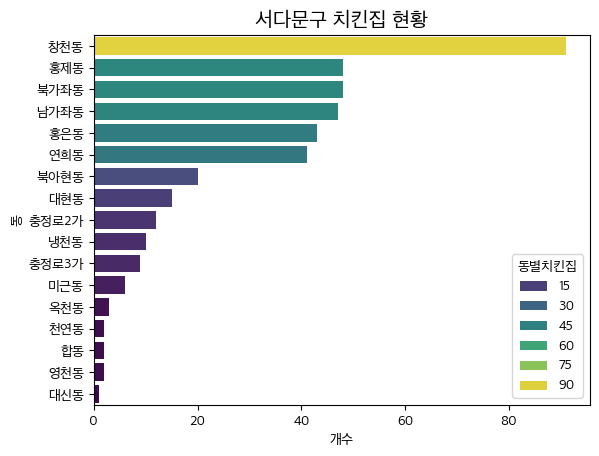

In [268]:
chicken_df_result_sd_sorted = chicken_df_result_sd_grouped.sort_values(by='개방자치단체코드', ascending=False)
sns.barplot(x='개방자치단체코드', y=chicken_df_result_sd_sorted.index, data=chicken_df_result_sd_sorted, palette='viridis', hue='개방자치단체코드')
plt.title('서다문구 치킨집 현황', fontsize=15)
plt.xlabel('개수')
plt.ylabel('동')
plt.legend(title='동별치킨집')
plt.show()

In [273]:
chicken_df_result_grouped = chicken_df_result.groupby('구이름').count()
chicken_df_result_grouped

,개방자치단체코드,상세영업상태코드,상세영업상태명,소재지전체주소,도로명전체주소,업태구분명,위생업태명,동이름,동별치킨집
구이름,,,,,,,,,
강남구,436,436,436,435,435,436,436,436,436
강동구,605,605,605,605,603,605,605,605,605
강북구,495,495,495,495,491,495,495,495,495
강서구,625,625,625,625,623,625,625,625,625
관악구,694,694,694,693,694,694,694,694,694
광진구,650,650,650,650,644,650,650,650,650
구로구,783,783,783,783,770,783,783,783,783
금천구,479,479,479,479,478,479,479,479,479
노원구,586,586,586,586,584,586,586,586,586


<Axes: xlabel='개방자치단체코드', ylabel='구이름'>

Text(0.5, 1.0, '서울특별시 구별 치킨집 현황')

Text(0.5, 0, '개수')

Text(0, 0.5, '구')

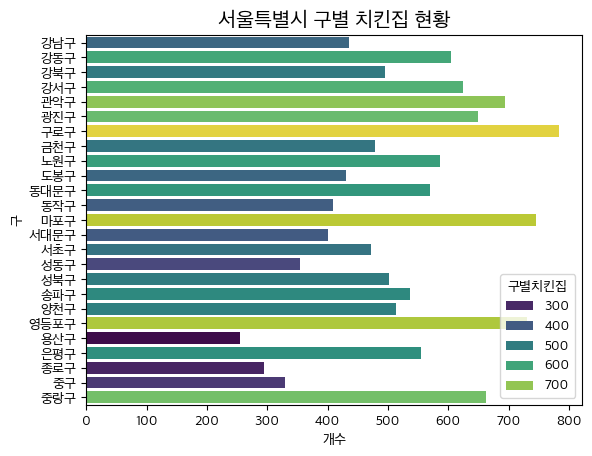

In [277]:
chicken_df_result_sorted = chicken_df_result_grouped.sort_values(by='개방자치단체코드', ascending=False)
sns.barplot(x='개방자치단체코드', y=chicken_df_result_grouped.index, data=chicken_df_result_grouped, palette='viridis', hue='개방자치단체코드')
plt.title('서울특별시 구별 치킨집 현황', fontsize=15)
plt.xlabel('개수')
plt.ylabel('구')
plt.legend(title='구별치킨집')
plt.show()

In [282]:
chicken_df_result_grouped2 = chicken_df_result.groupby(['개방자치단체코드', '구이름']).count()
chicken_df_result_grouped2

,,상세영업상태코드,상세영업상태명,소재지전체주소,도로명전체주소,업태구분명,위생업태명,동이름,동별치킨집
개방자치단체코드,구이름,,,,,,,,
3000000,종로구,294,294,293,290,294,294,294,294
3010000,중구,329,329,329,322,329,329,329,329
3020000,용산구,255,255,255,255,255,255,255,255
3030000,성동구,355,355,355,348,355,355,355,355
3040000,광진구,650,650,650,644,650,650,650,650
3050000,동대문구,570,570,570,547,570,570,570,570
3060000,중랑구,663,663,663,663,663,663,663,663
3070000,성북구,501,501,500,491,501,501,501,501
3080000,강북구,495,495,495,491,495,495,495,495
